<a href="https://colab.research.google.com/github/ansh-arch09/Random-forest-CarPrediction-project-/blob/main/vehicle%20type%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# Install Kaggle
!pip -q install kaggle

# Download dataset directly from Kaggle
!kaggle datasets download -d kaggleashwin/vehicle-type-recognition

# Unzip dataset
!unzip -q vehicle-type-recognition.zip -d vehicle_dataset

print("Dataset downloaded and extracted successfully!")

Dataset URL: https://www.kaggle.com/datasets/kaggleashwin/vehicle-type-recognition
License(s): apache-2.0
100% 159M/159M [00:01<00:00, 95.1MB/s]

Dataset downloaded and extracted successfully!


In [ ]:
import os

dataset_path = "/content/vehicle_dataset"

print("Dataset path:", dataset_path)
print("\nFiles/Folders:")

for item in os.listdir(dataset_path):
    print(item)

Dataset path: /content/vehicle_dataset

Files/Folders:
Dataset


In [ ]:
import os

dataset_path = "/content/vehicle_dataset/Dataset"

print("Classes/Folders:")

for item in os.listdir(dataset_path):
    print(item)

Classes/Folders:
Bus
Car
Truck
motorcycle


In [ ]:
import tensorflow as tf

dataset_path = "/content/vehicle_dataset/Dataset"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 123

train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_data.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Found 400 files belonging to 4 classes.
Using 320 files for training.
Found 400 files belonging to 4 classes.
Using 80 files for validation.
Classes: ['Bus', 'Car', 'Truck', 'motorcycle']
Number of classes: 4


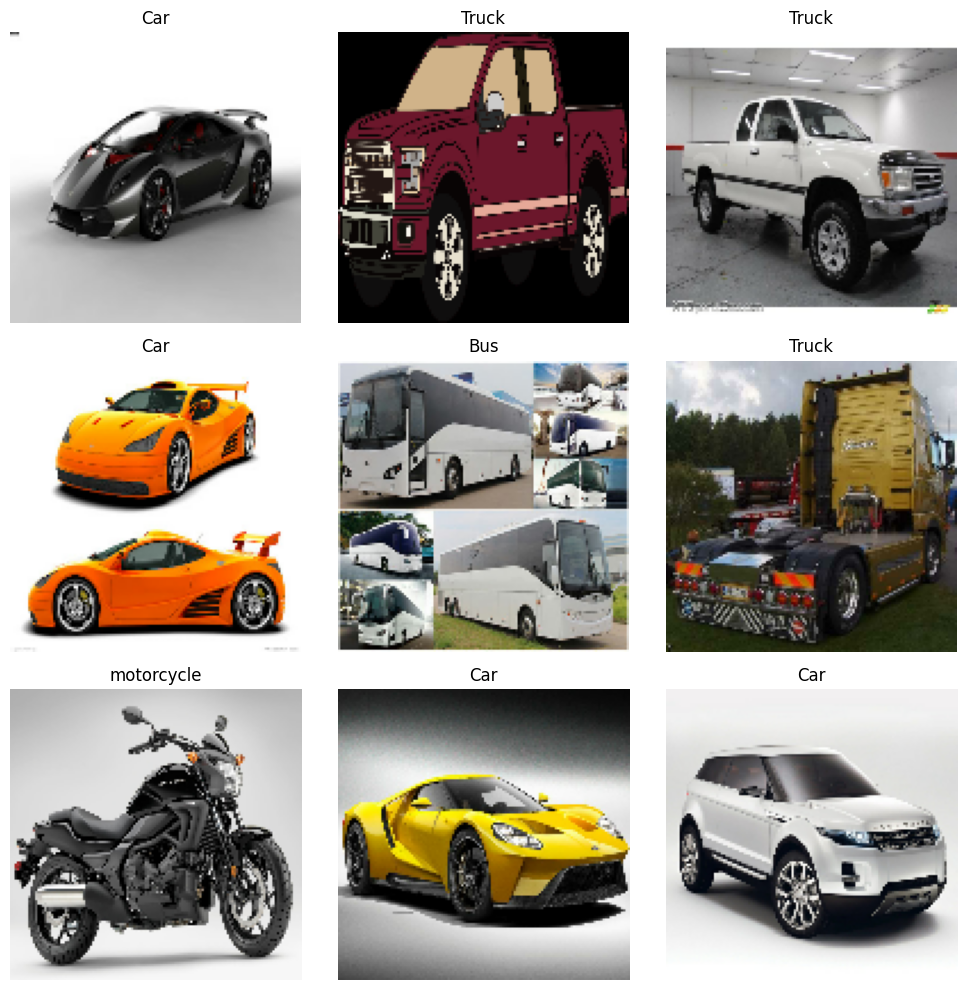

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 15

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.2406 - loss: 1.7128 - val_accuracy: 0.2750 - val_loss: 1.3881
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.2875 - loss: 1.3781 - val_accuracy: 0.3250 - val_loss: 1.3780
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.3375 - loss: 1.3612 - val_accuracy: 0.2750 - val_loss: 1.3666
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.4062 - loss: 1.2912 - val_accuracy: 0.4125 - val_loss: 1.3036
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.5125 - loss: 1.1710 - val_accuracy: 0.4125 - val_loss: 1.1583
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.5000 - loss: 1.0849 - val_accuracy: 0.4500 - val_loss: 1.2043
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5562 - loss: 1.0155 - val_accuracy: 0.6125 - val_loss: 1.0549
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5906 - loss: 0.8974 - val_accuracy: 0.6500 - val_loss:

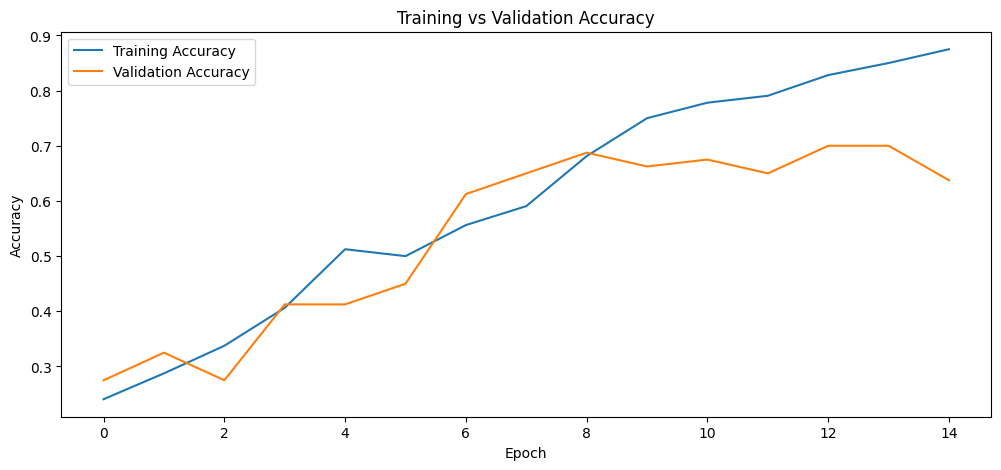

In [ ]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

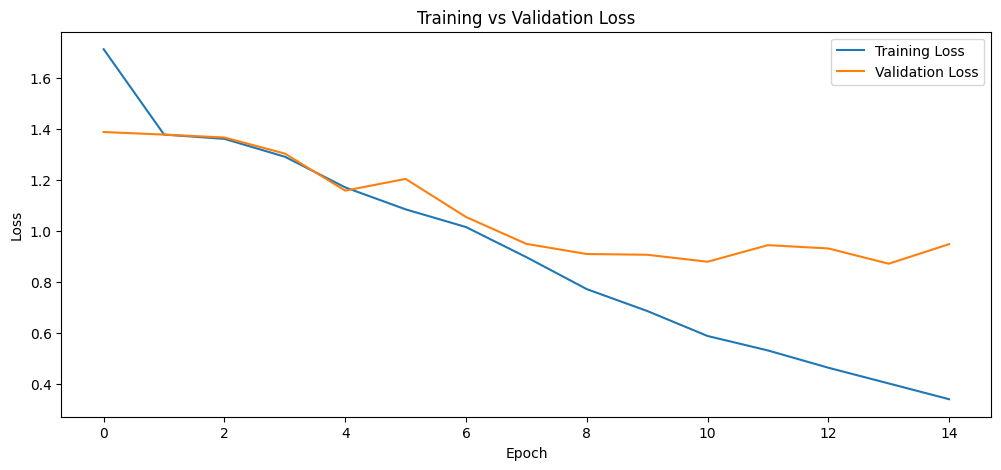

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


In [ ]:
loss, accuracy = model.evaluate(val_data)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)
print("Validation Accuracy (%):", accuracy * 100)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 476ms/step - accuracy: 0.6375 - loss: 0.9485
Validation Loss: 0.948456883430481
Validation Accuracy: 0.637499988079071
Validation Accuracy (%): 63.749998807907104


In [ ]:
import numpy as np

for images, labels in val_data.take(1):
    predictions = model.predict(images)

    predicted_classes = np.argmax(predictions, axis=1)

    print("Actual labels:   ", labels.numpy())
    print("Predicted labels:", predicted_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
Actual labels:    [0 3 2 0 0 1 3 1 2 0 1 3 1 3 0 0 3 2 0 3 0 0 1 0 3 3 3 1 0 0 3 1]
Predicted labels: [2 3 2 0 0 1 3 1 2 1 1 3 1 3 0 0 3 0 2 3 2 1 1 1 3 3 3 1 0 2 3 2]


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_data:
    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[10  6  5  1]
 [ 0 12  2  2]
 [ 2  3  7  4]
 [ 1  1  2 22]]


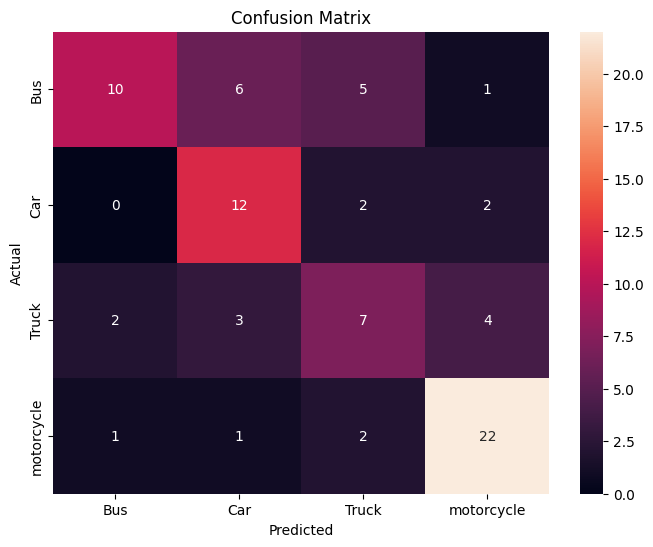

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

         Bus       0.77      0.45      0.57        22
         Car       0.55      0.75      0.63        16
       Truck       0.44      0.44      0.44        16
  motorcycle       0.76      0.85      0.80        26

    accuracy                           0.64        80
   macro avg       0.63      0.62      0.61        80
weighted avg       0.65      0.64      0.63        80



In [ ]:
model.save("/content/vehicle_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print(os.path.exists("/content/vehicle_cnn.keras"))

True


In [ ]:
from google.colab import files

files.download("/content/vehicle_cnn.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 879e65789b3abecf7d565b189b343ec3.jpg to 879e65789b3abecf7d565b189b343ec3.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


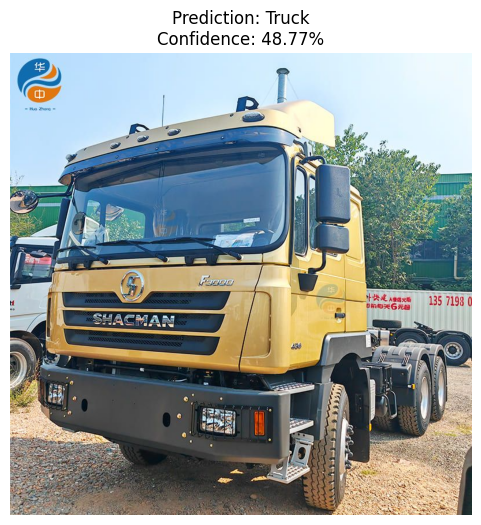

Predicted Vehicle: Truck
Confidence: 48.77%


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = list(uploaded.keys())[0]
img = Image.open(image_path).convert("RGB")
img_resized = img.resize((128, 128))
img_array = np.array(img_resized)
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)

predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

# Image display
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print("Predicted Vehicle:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    # Data Augmentation
    data_augmentation,

    # Normalize pixels
    tf.keras.layers.Rescaling(1./255),

    # CNN Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # CNN Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # CNN Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Classification
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        len(class_names),
        activation="softmax"
    )
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.2531 - loss: 1.4878 - val_accuracy: 0.3250 - val_loss: 1.3652
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.2937 - loss: 1.3784 - val_accuracy: 0.2125 - val_loss: 1.4047
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.3187 - loss: 1.3676 - val_accuracy: 0.2875 - val_loss: 1.3430
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.3281 - loss: 1.3355 - val_accuracy: 0.3000 - val_loss: 1.3280
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.4125 - loss: 1.2624 - val_accuracy: 0.5750 - val_loss: 1.2291
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5063 - loss: 1.1706 - val_accuracy: 0.5500 - val_loss: 1.1440
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5406 - loss: 1.1574 - val_accuracy: 0.5250 - val_loss: 1.2102
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.5312 - loss: 1.0661 - val_accuracy: 0.5625 - val_loss:

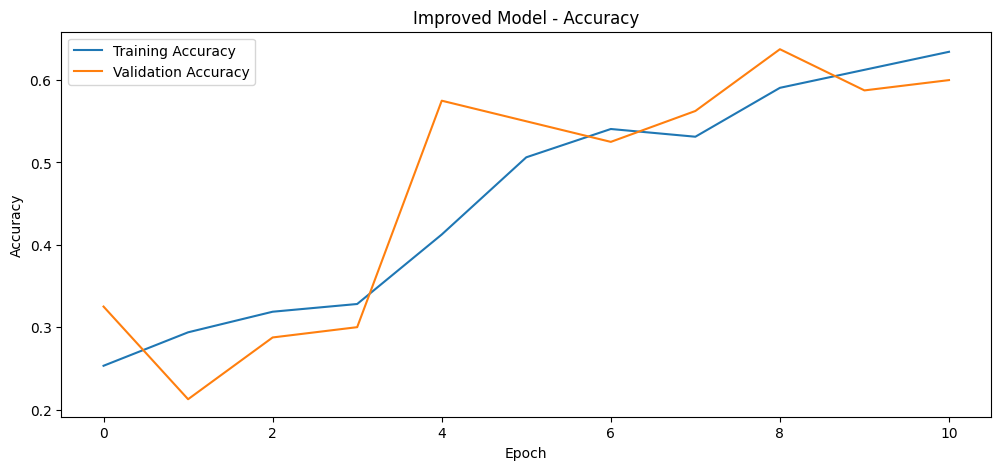

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved Model - Accuracy")
plt.legend()
plt.show()